In [1]:
import pandas as pd
import numpy as np
import anytree
import matplotlib.pyplot as plt
from anytree import Node, RenderTree
from anytree.exporter import DotExporter
from PIL import Image
from IPython.display import SVG

## Analisis inical del dataset

In [2]:
dataset = pd.read_csv('dataset.csv')

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
dataset.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
dataset.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

### Seleccionar las columnas requeridas para el proyecto

In [6]:
columnas_interesantes = ['Department',
                    'JobLevel',
                    'JobRole',
                    'MonthlyIncome',
                    'PerformanceRating',
                      'YearsAtCompany'
                    ]

In [7]:
dataset_interes = dataset[columnas_interesantes].copy()

In [8]:
dataset_interes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Department         1470 non-null   object
 1   JobLevel           1470 non-null   int64 
 2   JobRole            1470 non-null   object
 3   MonthlyIncome      1470 non-null   int64 
 4   PerformanceRating  1470 non-null   int64 
 5   YearsAtCompany     1470 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 69.0+ KB


In [9]:
dataset_interes.sample(10)

,Department,JobLevel,JobRole,MonthlyIncome,PerformanceRating,YearsAtCompany
158,Sales,3,Sales Executive,10855,3,12
30,Research & Development,1,Laboratory Technician,2496,3,1
542,Research & Development,3,Manufacturing Director,7861,3,1
215,Sales,3,Manager,13591,3,1
603,Research & Development,1,Research Scientist,2274,3,1
433,Sales,3,Sales Executive,9071,3,3
924,Research & Development,1,Research Scientist,3506,3,3
1367,Research & Development,1,Research Scientist,2226,3,5
373,Research & Development,1,Laboratory Technician,3816,3,5
1462,Sales,4,Sales Executive,12031,3,20


In [10]:
dataset_interes[['Department']].value_counts()

Department            
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

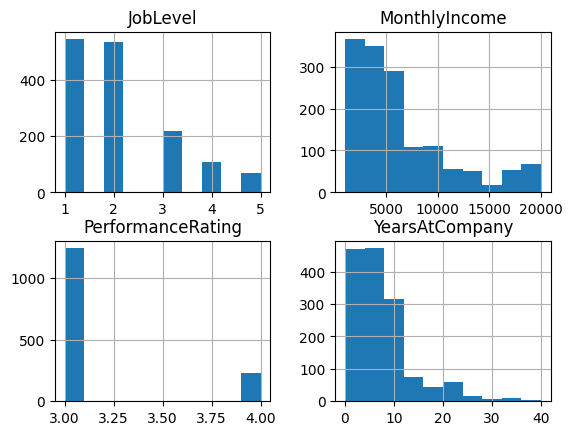

In [11]:
dataset_interes.hist();

### Observar la relacion etre Departamento, Roles y Niveles /
Parece ser q los los niveles concuerda con los roles, a excepcion del Rol de ResearchDirector que puede tener haste 3 niveles

In [12]:
dataset_interes.select_dtypes(include='object').value_counts()

Department              JobRole                  
Sales                   Sales Executive              326
Research & Development  Research Scientist           292
                        Laboratory Technician        259
                        Manufacturing Director       145
                        Healthcare Representative    131
Sales                   Sales Representative          83
Research & Development  Research Director             80
                        Manager                       54
Human Resources         Human Resources               52
Sales                   Manager                       37
Human Resources         Manager                       11
Name: count, dtype: int64

In [13]:
dataset_interes[['Department','JobRole', 'JobLevel']].value_counts()

Department              JobRole                    JobLevel
Research & Development  Research Scientist         1           234
Sales                   Sales Executive            2           233
Research & Development  Laboratory Technician      1           200
                        Manufacturing Director     2            90
Sales                   Sales Executive            3            79
Research & Development  Healthcare Representative  2            78
Sales                   Sales Representative       1            76
Research & Development  Research Scientist         2            57
                        Laboratory Technician      2            56
                        Manufacturing Director     3            45
                        Healthcare Representative  3            44
Human Resources         Human Resources            1            33
Research & Development  Research Director          3            28
                                                   5            26
  

## Construccion del sistema jerarquico en Forma de Arbol

In [14]:
from anytree import NodeMixin, RenderTree


### Definir clases para las entidades

In [15]:

"""
Plantilla de Clases Recursivas
(define (fn-for-empleado p)
  (...  (empleado-rol p)
        (empleado-sueldo-mensual p)
        (empleado-nivel p)

       (fn-for-lo-empleados (empleados-subordinados p))))  ;mutual recursion from mutual-reference"""

class Empleado(NodeMixin):
  def __init__(self, rol:str=None, sueldo_mensual:int=None, nivel:int=None) -> None:
    self.rol = rol
    self.sueldo_mensual = sueldo_mensual
    self.nivel = nivel
    #self.subordinados = subordinados if subordinados is not None else []

  
  
  def numero_de_subordinados(self):
    def contar_subordinados(subs:tuple["Empleado"]):
      #print(len(subs))
      if len(subs) == 0:
        #print('zero')
        return 0
      else:
        primero = subs[0]
        #print(primero)
        #print(subs[1:])
        return 1 + primero.numero_de_subordinados() + contar_subordinados(subs[1:])
    return contar_subordinados(self.children)
  def insertar_subordinado(self, un_subordinado:"Empleado"):
    # 1º Caso base: la diferencia de niveles == 1 , indica que es hijo directo
    if self.nivel - un_subordinado.nivel == 1:
      #self.subordinados.append(un_subordinado)
      un_subordinado.parent = self
      return True
      print('diferencia 1')
    # 2º Caso base: no hay diferencia de niveles, indica que es "hermano" ->
    if self.nivel == un_subordinado.nivel:
      un_subordinado.parent = self.parent
      return True
    # Caso recursivo: intentar insertarlo en alguno de los subordinados existentes
    for hijo in self.children:
        if hijo.insertar_subordinado(un_subordinado):
          #print('insertado en sub subordinado')
          return True
    #Caso si no hay subordinados o la difenrencia de niveles es mayor a 1
    un_subordinado.parent = self
    #print('insertado en subordniados n1')
    return True
  
  def calcular_sueldo_mas_subordinados(self):

    def calcular_sueldo_subordinados(subordinados:tuple["Empleado"]):
      if not subordinados:
        return 0
      else:
        primero = subordinados[0]
        resto = subordinados[1:]
        return primero.calcular_sueldo_mas_subordinados() + calcular_sueldo_subordinados(resto)

    return self.sueldo_mensual + calcular_sueldo_subordinados(self.children)
  
  def __str__(self):
    return f'{self.rol}; Sueldo: {self.sueldo_mensual}; Nivel: {self.nivel}'
  @property
  def name(self):
      # Usamos __str__ para que coincida con tu representación
    
      return self.__str__()



    




class Departamento(NodeMixin):
  def __init__(self, nombre_dpto:str) -> None:
    self.name_dpto = nombre_dpto
    
  
  def insertar_empleado(self, un_empleado:Empleado):
    # 1º Caso base: No hay aun empleados
    if not self.children:
      #self.subordinados.append(un_subordinado)
      un_empleado.parent = self
      return True
      print('diferencia 1')
    # Caso recursivo: intentar insertarlo en alguno de los emplleados existentes
    for hijo in self.children:
        if hijo.insertar_subordinado(un_empleado):
          #print('insertado en sub subordinado')
          return True
  def presupesto_total(self):
    total = 0
    for empleado in self.children:
      total += empleado.calcular_sueldo_mas_subordinados()
    return total
  
  def numero_empleados(self):
    total = 0
    for empleado in self.children:
      total += 1
      total += empleado.numero_de_subordinados()
    return total
  
  def __str__(self):
    presupuesto = self.presupesto_total()
    return f'Departamento: {self.name_dpto} ; Presupuesto: {presupuesto} ; Numero de Emepleados: {self.numero_empleados()}'
  
  @property
  def name(self):
      # Usamos __str__ para que coincida con tu representación
    
      return self.__str__()
  

  






###  Alistar el Dataset para construir el Arbol

In [16]:
agrupamiento = ['Department','JobLevel']

In [17]:
def construir_arbol(df:pd.DataFrame):
    empresa = Node('Empresa')

    agrupamiento = ['Department','JobLevel']

    df = df.set_index(agrupamiento).sort_index(ascending=False)

    primera_fila = df.iloc[0]
    primer_indice = primera_fila.name[0]
    segundo_indice = primera_fila.name[1]
    depto_actual = Departamento(primer_indice)
    depto_actual.parent = empresa

    for (i1, i2), row in df.iterrows():
        
        if i1 != primer_indice:
            depto_actual = Departamento(i1)
            depto_actual.parent = empresa
            primer_indice = i1
        empleado_row = Empleado(row['JobRole'], row['MonthlyIncome'], i2)
        depto_actual.insertar_empleado(empleado_row)

    return empresa
    
    


In [18]:
empresa = construir_arbol(dataset_interes)
for pre, fill, node in RenderTree(empresa):
    print(f'{pre} {node}')

 Node('/Empresa')
├──  Departamento: Sales ; Presupuesto: 3103791 ; Numero de Emepleados: 446
│   ├──  Manager; Sueldo: 18947; Nivel: 5
│   │   ├──  Manager; Sueldo: 15427; Nivel: 4
│   │   │   ├──  Sales Executive; Sueldo: 8726; Nivel: 3
│   │   │   │   ├──  Sales Executive; Sueldo: 5993; Nivel: 2
│   │   │   │   │   ├──  Sales Representative; Sueldo: 3407; Nivel: 1
│   │   │   │   │   ├──  Sales Representative; Sueldo: 2683; Nivel: 1
│   │   │   │   │   ├──  Sales Representative; Sueldo: 2014; Nivel: 1
│   │   │   │   │   ├──  Sales Representative; Sueldo: 2322; Nivel: 1
│   │   │   │   │   ├──  Sales Representative; Sueldo: 1675; Nivel: 1
│   │   │   │   │   ├──  Sales Representative; Sueldo: 2231; Nivel: 1
│   │   │   │   │   ├──  Sales Representative; Sueldo: 2325; Nivel: 1
│   │   │   │   │   ├──  Sales Representative; Sueldo: 3140; Nivel: 1
│   │   │   │   │   ├──  Sales Representative; Sueldo: 2793; Nivel: 1
│   │   │   │   │   ├──  Sales Representative; Sueldo: 3931; Nivel: 1


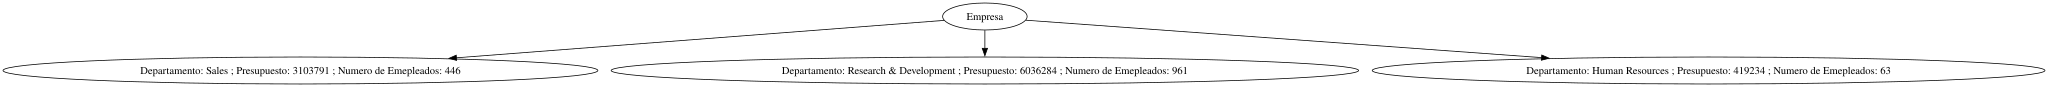

In [19]:
#Exportar el arbol con profundidad 1
profundidad = 1
nombre_imagen = f'empresa_{profundidad}_niveles.svg'


DotExporter(
    empresa,
    filter_= lambda node: node.depth <= profundidad
).to_picture(nombre_imagen)

SVG(nombre_imagen)

In [20]:
#Exportar el arbol con profundidad 2
profundidad = 2
nombre_imagen = f'empresa_{profundidad}_niveles.svg'


DotExporter(
    empresa,
    filter_= lambda node: node.depth <= profundidad
).to_picture(nombre_imagen)

SVG(nombre_imagen)